In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import os


df_list = []
for item in os.listdir("results/"):
    df = pd.read_csv("results/" + item)
    df_list.append(df.copy())
df = pd.concat(df_list, ignore_index=True)

df['x_parsed'] = df['x'].apply(lambda s: np.fromstring(s.strip('[]'), sep=' '))
df['x1'] = df['x_parsed'].apply(lambda arr: arr[0])
df['x2'] = df['x_parsed'].apply(lambda arr: arr[1])


In [7]:
synthetic priors 

SyntaxError: invalid syntax (2137493244.py, line 1)

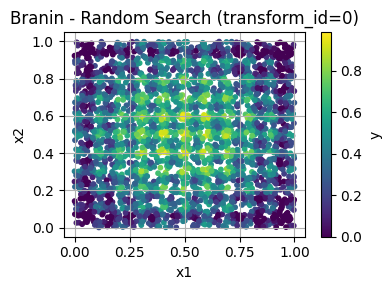

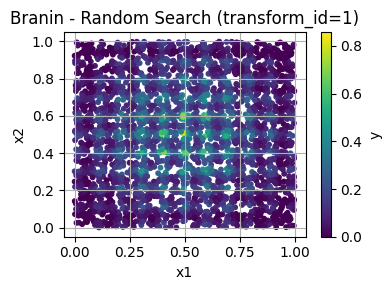

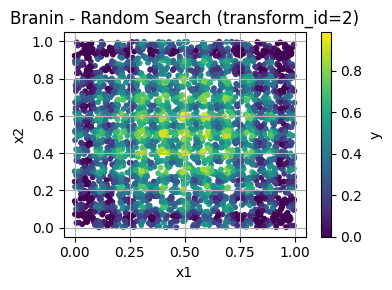

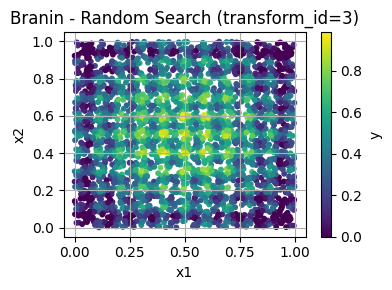

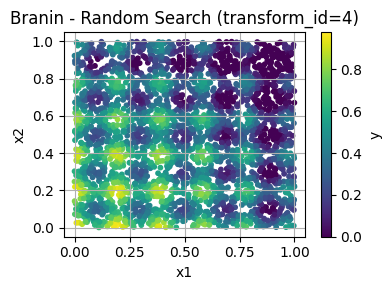

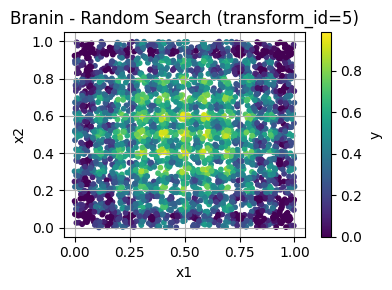

In [2]:
method = 'Random-Search'
function_name = "Rastrigin"
dfm = df[(df['method'] == method) & (df['function_name'] == function_name)]
# Plot for each transform_id
unique_transforms = dfm['transform_id'].unique()

for transform_id in unique_transforms:
    df_subset = dfm[dfm['transform_id'] == transform_id]
    
    plt.figure(figsize=(4, 3))
    sc = plt.scatter(df_subset['x1'], df_subset['x2'], c=df_subset['y'], cmap='viridis', s=10)
    plt.colorbar(sc, label='y')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'Branin - Random Search (transform_id={transform_id})')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

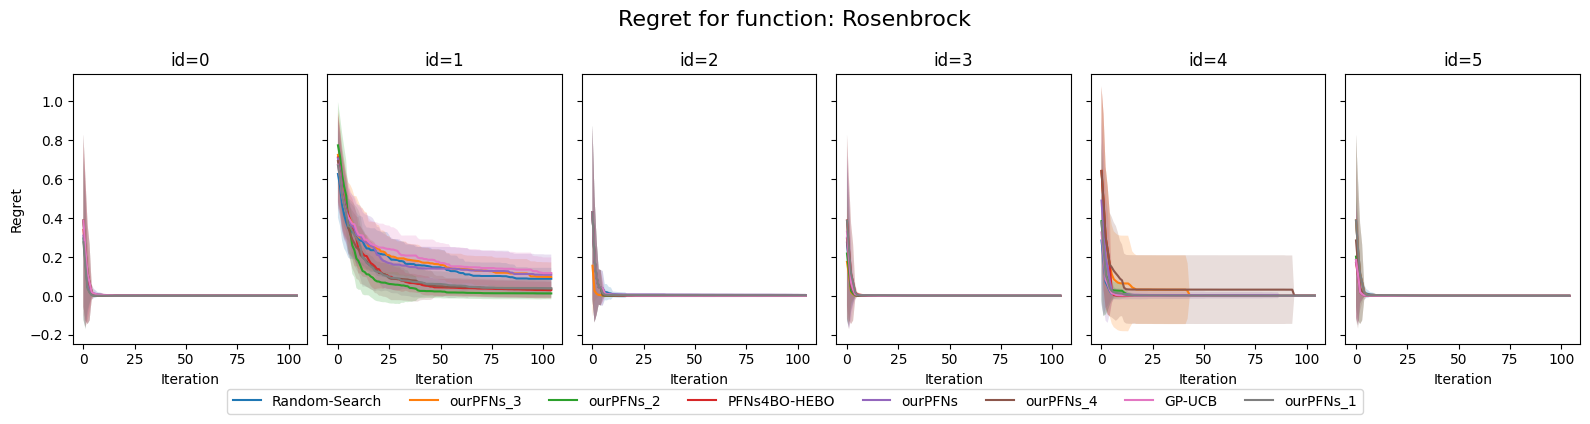

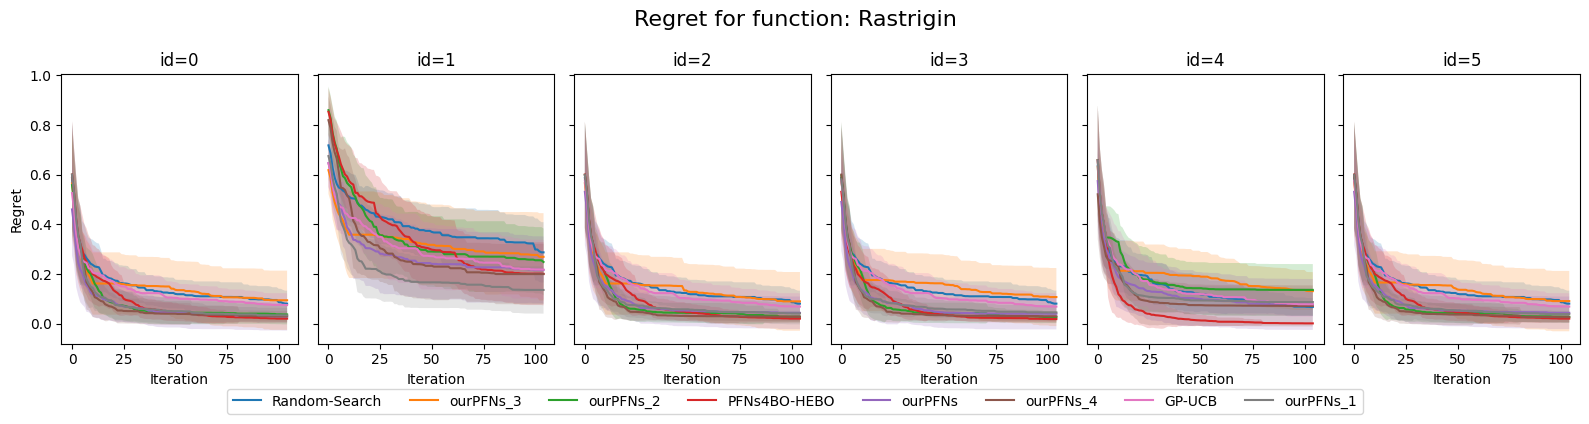

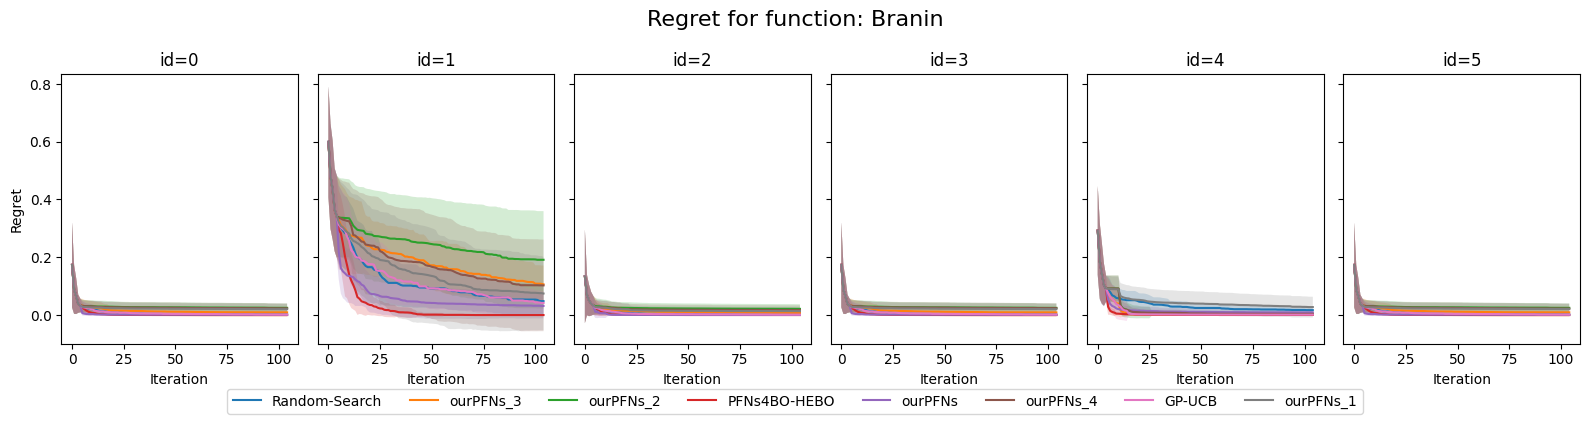

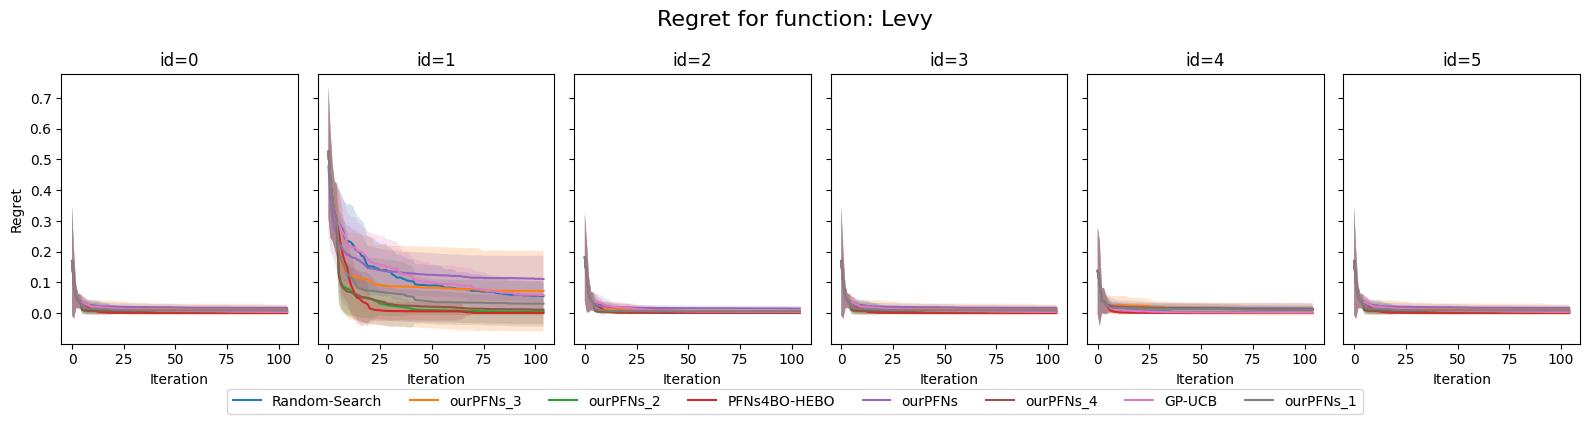

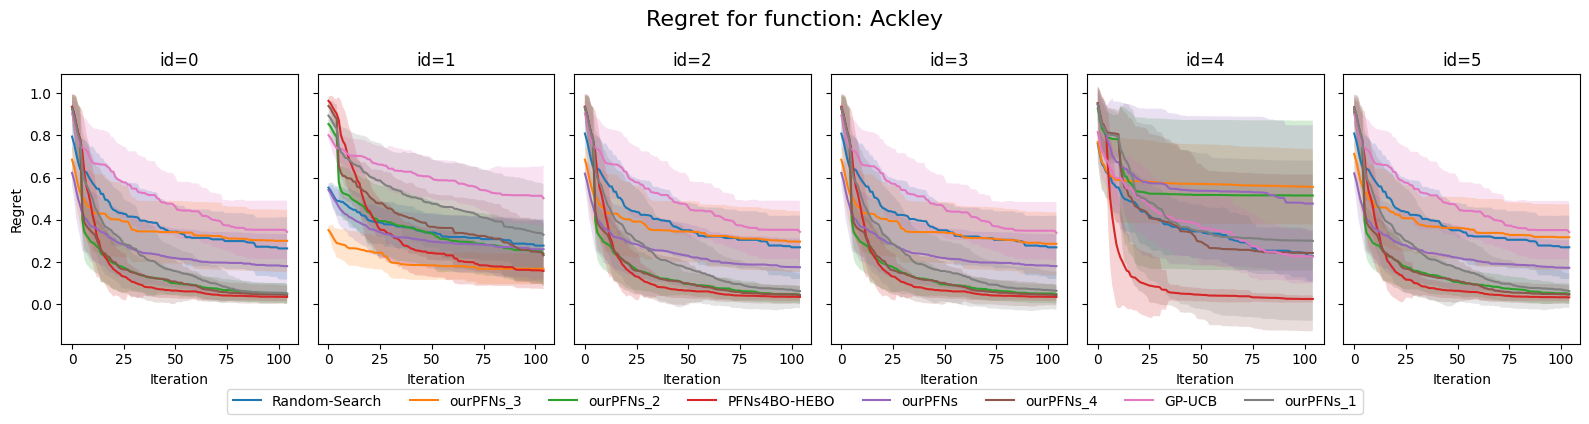

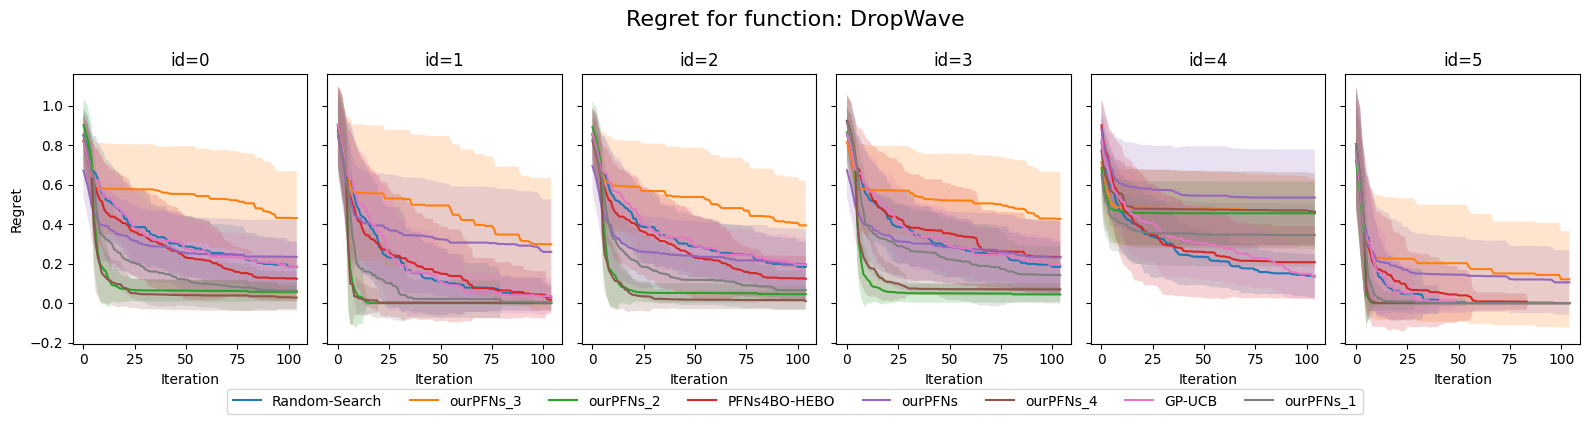

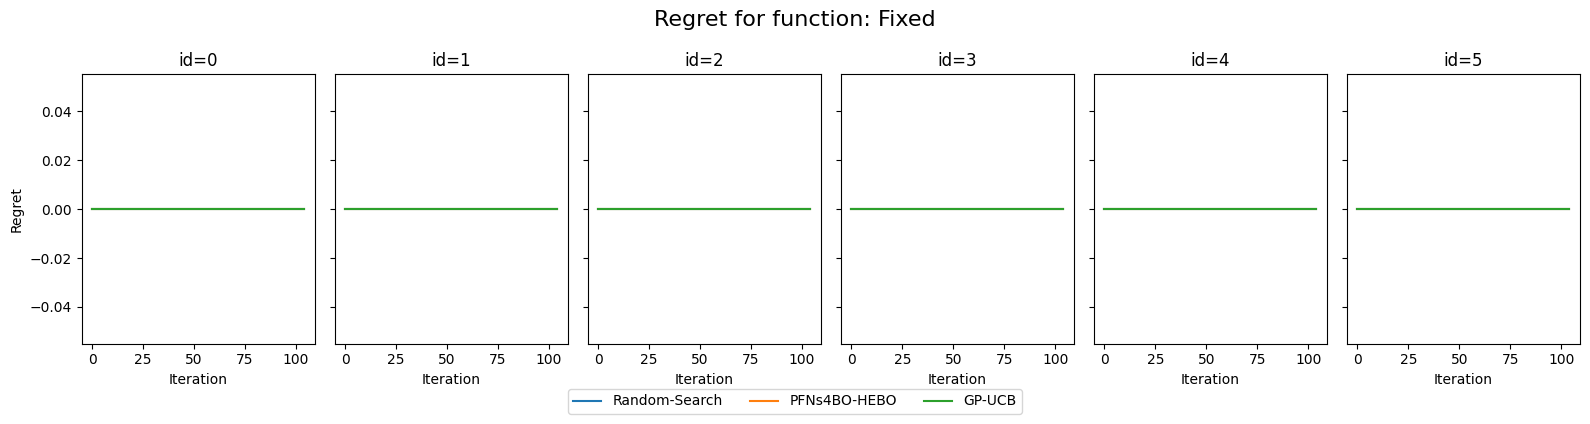

In [8]:
import matplotlib.pyplot as plt

function_names = df['function_name'].unique()
methods = df['method'].unique()

for function_name in function_names:
    fig, axes = plt.subplots(1, 6, figsize=(16, 4), sharey=True)  # 6 plots in one row
    handles = []
    labels = []
    collected_legend = False  # To avoid collecting multiple times
    for i, transform_id in enumerate(sorted(df['transform_id'].unique())):
        ax = axes[i]
        for method in methods:
            df_sub = df[
                (df['transform_id'] == transform_id) &
                (df['method'] == method) &
                (df['function_name'] == function_name)
            ]
            if df_sub.empty:
                continue
            y_star = df_sub['y'].max()
            pivot = df_sub.pivot(index='iteration', columns='seed', values='y').sort_index()
            incumbent = pivot.cummax()
            regret =  y_star - incumbent
            mean_regret = regret.mean(axis=1)
            std_regret = regret.std(axis=1)

            line, = ax.plot(mean_regret.index, mean_regret.values, label=method)
            ax.fill_between(mean_regret.index,
                            mean_regret - std_regret,
                            mean_regret + std_regret,
                            alpha=0.2)
            if not collected_legend:
                handles.append(line)
                labels.append(method)
                

        ax.set_title(f"id={transform_id}")
        ax.set_xlabel("Iteration")
        if i == 0:
            ax.set_ylabel("Regret")
        collected_legend = True

    fig.suptitle(f"Regret for function: {function_name}", fontsize=16)
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 0.05))
    fig.tight_layout()
    plt.show()


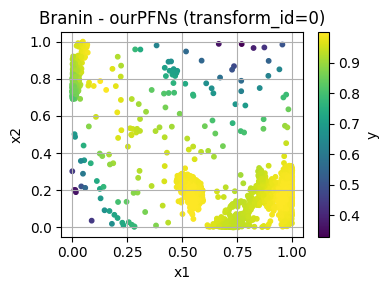

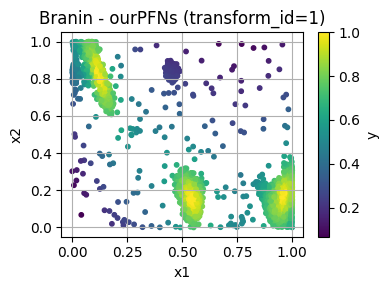

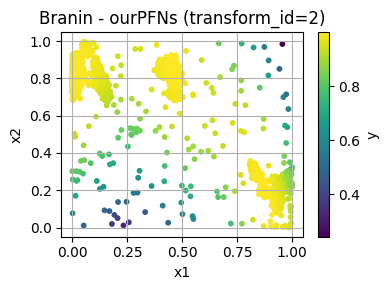

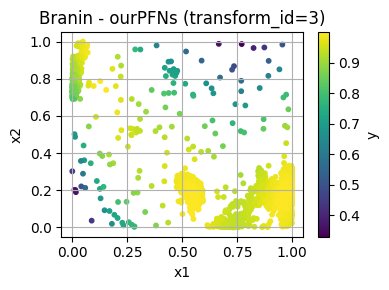

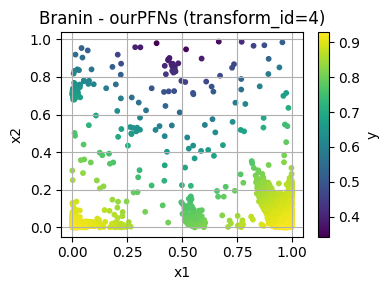

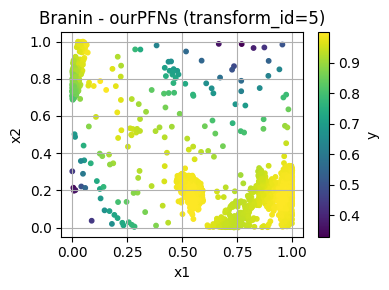

In [13]:
method = 'ourPFNs'
function_name = "Branin"
dfm = df[(df['method'] == method) & (df['function_name'] == function_name)]
# Plot for each transform_id
unique_transforms = dfm['transform_id'].unique()

for transform_id in unique_transforms:
    df_subset = dfm[dfm['transform_id'] == transform_id]
    
    plt.figure(figsize=(4, 3))
    sc = plt.scatter(df_subset['x1'], df_subset['x2'], c=df_subset['y'], cmap='viridis', s=10)
    plt.colorbar(sc, label='y')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'{function_name} - {method} (transform_id={transform_id})')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

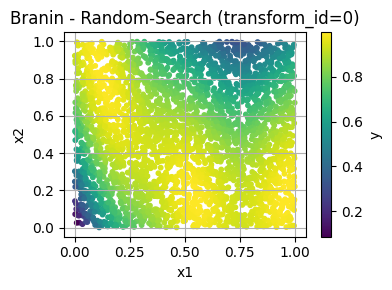

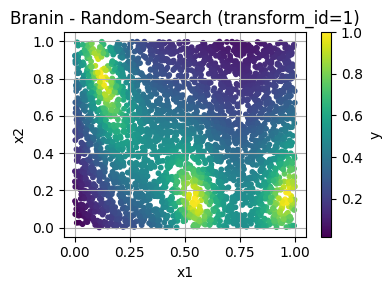

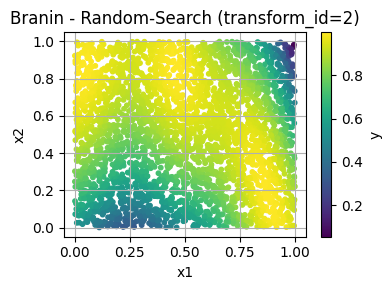

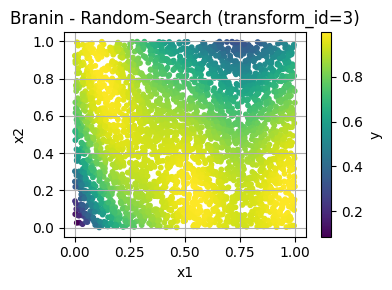

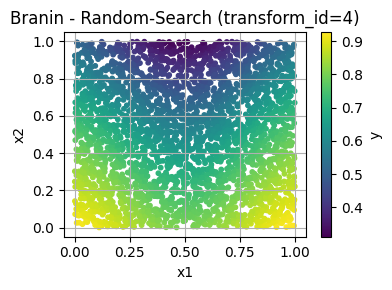

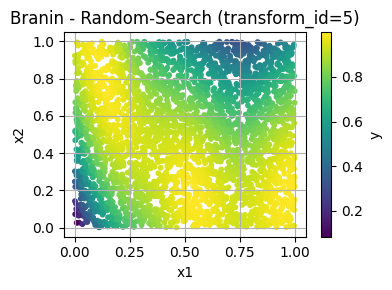

In [ ]:
method = 'Random-Search'
function_name = "Branin"
dfm = df[(df['method'] == method) & (df['function_name'] == function_name)]
# Plot for each transform_id
unique_transforms = dfm['transform_id'].unique()

for transform_id in unique_transforms:
    df_subset = dfm[dfm['transform_id'] == transform_id]
    
    plt.figure(figsize=(4, 3))
    sc = plt.scatter(df_subset['x1'], df_subset['x2'], c=df_subset['y'], cmap='viridis', s=10)
    plt.colorbar(sc, label='y')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(f'{function_name} - {method} (transform_id={transform_id})')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

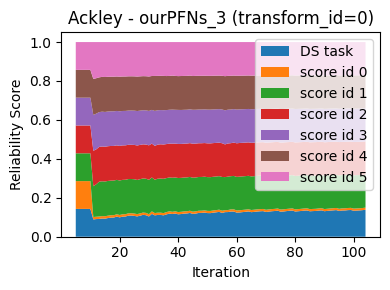

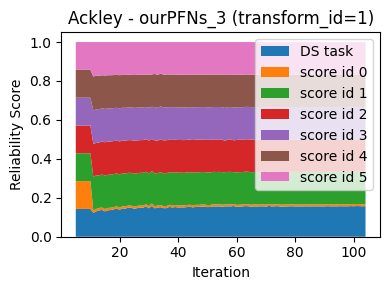

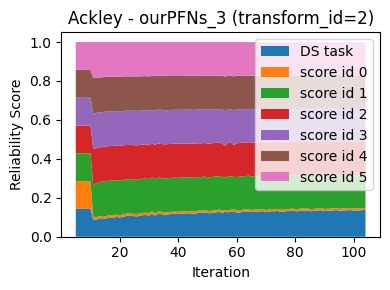

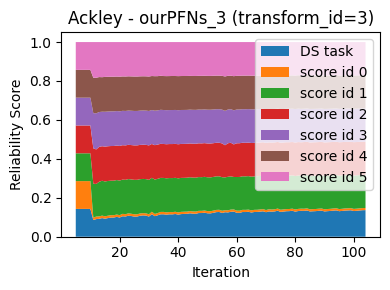

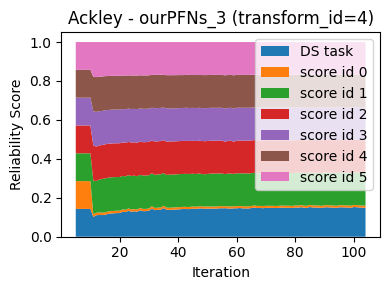

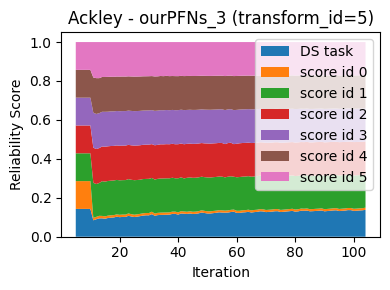

In [26]:
method = 'ourPFNs_3'
function_name = "Ackley"
dfm = df[(df['method'] == method) & (df['function_name'] == function_name)]
# Plot for each transform_id
unique_transforms = dfm['transform_id'].unique()

def parse_scores(x):
    if isinstance(x, str):
        if "tensor" in x:
            # Remove 'tensor(' and ')' and convert to numpy array
            x = x.replace('tensor(', '').replace(')', '').strip('[]')
        else:
            # Handle string representation of a list
           x = x.strip('[]')
        return np.array([float(i.strip()) if i.strip() != 'nan' else np.nan for i in x.split(',')])
    return np.array(x)


for transform_id in unique_transforms:
    df_subset = dfm[(dfm['transform_id'] == transform_id) & (dfm['iteration'] >= 5)].copy()

    df_subset['scores'] = df_subset['reliability_scores'].apply(parse_scores)

    score_cols = [f'DS task' if i==0 else f'score id {i -1}' for i in range(len(df_subset['scores'].iloc[0]))]

    df_subset[score_cols] = pd.DataFrame(df_subset['scores'].tolist(), index=df_subset.index)
    
    agg_df = df_subset.groupby('iteration')[score_cols].mean()  # or .median()

    plt.figure(figsize=(4, 3))
    plt.stackplot(agg_df.index, agg_df.values.T, labels=score_cols)
    plt.xlabel("Iteration")
    plt.ylabel("Reliability Score")
    plt.title(f'{function_name} - {method} (transform_id={transform_id})')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()